In [150]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from src.ps_dare.paths import solve_path

# load the data
PREDICTIONS_FILE_GIUSTINIANI = "data/weekly/predictions/" "general_giustiniani.csv"
PREDICTIONS_FILE_PEDIATRICO = "data/weekly/predictions/" "general_pediatrico.csv"
PREDICTIONS_FILE_OSA = "data/weekly/predictions/" "general_osa.csv"


df_giustiniani = pd.read_csv(solve_path(PREDICTIONS_FILE_GIUSTINIANI))
df_pediatrico = pd.read_csv(solve_path(PREDICTIONS_FILE_PEDIATRICO))
df_osa = pd.read_csv(solve_path(PREDICTIONS_FILE_OSA))

In [151]:
date_columns = ["date", "date_start_training", "date_end_training", "date_end_testing"]
for df in (df_giustiniani, df_pediatrico, df_osa):
    df[date_columns] = df[date_columns].apply(pd.to_datetime)

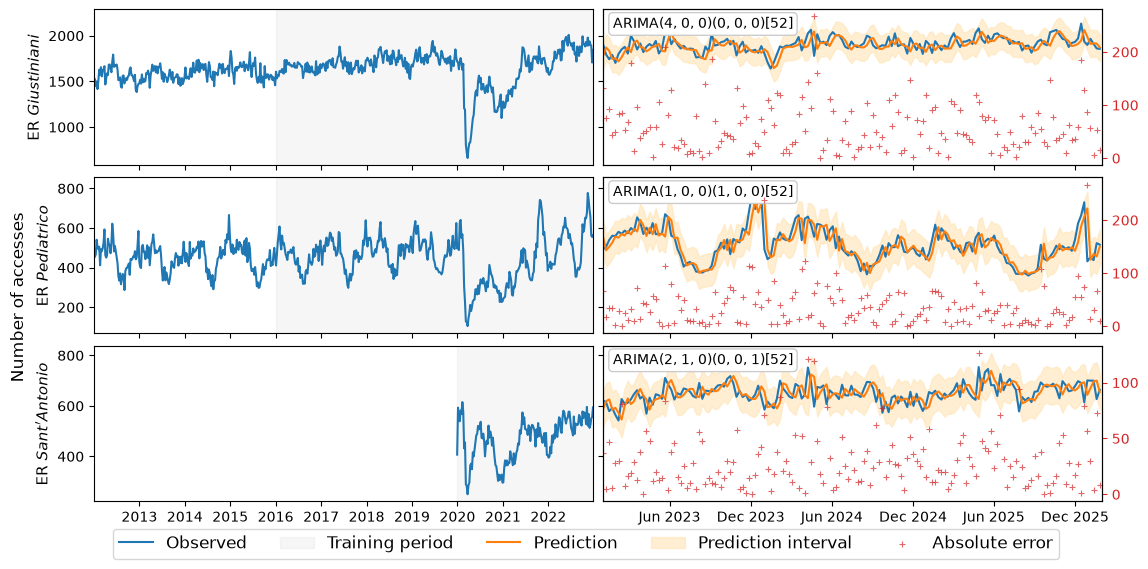

In [152]:
plt.rcParams.update({"font.size": 10})

datasets = [
    ("Giustiniani", df_giustiniani),
    ("Pediatrico", df_pediatrico),
    ("Sant'Antonio", df_osa),
]

history_start = min(
    df.loc[df["n_accesses"].notna(), "date"].min() for _, df in datasets
)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 6),
    sharex="col",
    sharey="row",
    gridspec_kw={"width_ratios": (1, 1)},
)

error_axes = []

for (ax_history, ax_test), (title, df) in zip(axes, datasets):
    training_start = df["date_start_training"].iloc[0]
    training_end = df["date_end_training"].iloc[0]
    testing_start = df.loc[df["phase"] == "testing", "date"].min()
    testing_end = df["date_end_testing"].iloc[0]
    order = tuple(int(df[column].iloc[0]) for column in ("p", "d", "q"))
    seasonal_order = tuple(int(df[column].iloc[0]) for column in ("P", "D", "Q"))
    history = df.loc[df["date"] <= training_end]
    test = df.loc[df["phase"] == "testing"]
    absolute_error = (test["prediction"] - test["n_accesses"]).abs()

    ax_history.plot(history["date"], history["n_accesses"], label="Observed")
    ax_history.axvspan(
        training_start,
        training_end,
        color="lightgray",
        alpha=0.2,
        label="Training period",
    )
    ax_history.set_xlim(history_start, history["date"].max())

    ax_test.plot(test["date"], test["n_accesses"], label="Observed")
    ax_test.plot(test["date"], test["prediction"], label="Prediction")
    ax_test.fill_between(
        test["date"],
        test["prediction_lower_bound"],
        test["prediction_upper_bound"],
        color="moccasin",
        alpha=0.6,
        label="Prediction interval",
    )
    ax_error = ax_test.twinx()
    ax_error.scatter(
        test["date"],
        absolute_error,
        marker="+",
        s=20,
        linewidths=0.8,
        color="tab:red",
        alpha=0.7,
        label="Absolute error",
    )

    ax_error.tick_params(axis="y", colors="tab:red")
    error_axes.append(ax_error)
    ax_test.set_xlim(testing_start, testing_end)

    ax_history.set_ylabel(rf"ER $\mathit{{{title}}}$", fontdict={"fontsize": 11})
    for ax in (ax_history, ax_test):
        ax.tick_params(axis="x", labelrotation=0)

    ax_test.text(
        0.02,
        0.86,
        f"ARIMA{order}{seasonal_order}[52]",
        transform=ax_test.transAxes,
        ha="left",
        va="bottom",
        # fontsize=10,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.8"},
    )
axes[-1, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[-1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.supylabel("Number of accesses")
history_handles, history_labels = axes[0, 0].get_legend_handles_labels()
test_handles, test_labels = axes[0, 1].get_legend_handles_labels()
error_handles, error_labels = error_axes[0].get_legend_handles_labels()
handles = history_handles + test_handles[1:] + error_handles
labels = history_labels + test_labels[1:] + error_labels
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=5,
    fontsize=12,
)
fig.subplots_adjust(
    left=0.09, right=0.93, bottom=0.16, top=0.98, hspace=0.08, wspace=0.02
)
plt.savefig(
    solve_path("graphs/fig1.pdf"),
    bbox_inches="tight",
)